In [1]:
import os
import cv2
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pdf2image import convert_from_path

In [2]:
images = convert_from_path("dataset/pdf/neyzen_com/hicaz/hicaz_longa_husnu_ustun_udi_huseyin.pdf", dpi=300)

In [3]:
images

[<PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=2480x3508>]

In [4]:
images[0].save("page1.png")

In [ ]:
# # polygon to bbx
# label_dir = "yolo_init/labels"

# for file in os.listdir(label_dir):
#     if not file.endswith(".txt"):
#         continue

#     path = os.path.join(label_dir, file)

#     new_lines = []

#     with open(path) as f:
#         lines = f.readlines()

#     for line in lines:
#         vals = list(map(float, line.split()))
#         cls = int(vals[0])
#         coords = vals[1:]

#         xs = coords[0::2]
#         ys = coords[1::2]

#         x_min = min(xs)
#         x_max = max(xs)
#         y_min = min(ys)
#         y_max = max(ys)

#         x_center = (x_min + x_max) / 2
#         y_center = (y_min + y_max) / 2
#         w = x_max - x_min
#         h = y_max - y_min

#         new_lines.append(f"{cls} {x_center} {y_center} {w} {h}\n")

#     with open(path, "w") as f:
#         f.writelines(new_lines)

In [27]:
# convert to tiles
INPUT_IMAGES = "yolo_init/images"
INPUT_LABELS = "yolo_init/labels"

OUTPUT_IMAGES = "yolo_tiled/images"
OUTPUT_LABELS = "yolo_tiled/labels"

TILE_SIZE = 1280     # Try 1024 or 1280
OVERLAP = 256        # Important for music notation

os.makedirs(OUTPUT_IMAGES, exist_ok=True)
os.makedirs(OUTPUT_LABELS, exist_ok=True)


# -----------------------------
# Helper Functions
# -----------------------------

def load_labels(label_path):
    boxes = []
    
    if not os.path.exists(label_path):
        return boxes
        
    with open(label_path) as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.strip().split())
            boxes.append([int(cls), x, y, w, h])
            
    return boxes


def save_labels(path, labels):
    with open(path, "w") as f:
        for l in labels:
            f.write(" ".join(map(str, l)) + "\n")


# -----------------------------
# Main Tiling Loop
# -----------------------------

image_files = list(Path(INPUT_IMAGES).glob("*.*"))

for img_path in image_files:
    
    print(f"Processing: {img_path.name}")
    
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    
    label_path = os.path.join(
        INPUT_LABELS,
        img_path.stem + ".txt"
    )
    
    labels = load_labels(label_path)
    
    # Convert normalized to absolute
    abs_boxes = []
    
    for cls, x, y, bw, bh in labels:
        x1 = (x - bw/2) * w
        y1 = (y - bh/2) * h
        x2 = (x + bw/2) * w
        y2 = (y + bh/2) * h
        
        abs_boxes.append([cls, x1, y1, x2, y2])
    
    
    stride = TILE_SIZE - OVERLAP
    
    tile_id = 0
    
    for y in range(0, h, stride):
        for x in range(0, w, stride):
            
            x_end = min(x + TILE_SIZE, w)
            y_end = min(y + TILE_SIZE, h)
            
            tile = img[y:y_end, x:x_end]
            
            tile_boxes = []
            
            for cls, x1, y1, x2, y2 in abs_boxes:
                
                # Intersection
                ix1 = max(x1, x)
                iy1 = max(y1, y)
                ix2 = min(x2, x_end)
                iy2 = min(y2, y_end)
                
                if ix1 < ix2 and iy1 < iy2:
                    
                    # convert to tile coords
                    tx1 = ix1 - x
                    ty1 = iy1 - y
                    tx2 = ix2 - x
                    ty2 = iy2 - y
                    
                    # normalize
                    tw = tile.shape[1]
                    th = tile.shape[0]
                    
                    cx = ((tx1 + tx2)/2) / tw
                    cy = ((ty1 + ty2)/2) / th
                    bw = (tx2 - tx1) / tw
                    bh = (ty2 - ty1) / th
                    
                    tile_boxes.append([
                        cls,
                        cx,
                        cy,
                        bw,
                        bh
                    ])
            
            
            if len(tile_boxes) > 0:
                
                tile_name = f"{img_path.stem}_{tile_id}.png"
                
                cv2.imwrite(
                    os.path.join(OUTPUT_IMAGES, tile_name),
                    tile
                )
                
                save_labels(
                    os.path.join(
                        OUTPUT_LABELS,
                        tile_name.replace(".png", ".txt")
                    ),
                    tile_boxes
                )
                
                tile_id += 1


print("Tiling complete!")

Processing: 08a9d36e-page1.png
Processing: f1f55240-page1.png
Processing: fc38b975-page2.png
Tiling complete!


In [17]:
IMAGE_DIR = "yolo_tiled/images"
LABEL_DIR = "yolo_tiled/labels"

# Optional: class names
CLASS_NAMES = [
    "barline",
    "comma_1_down",
    "comma_4_down",
    "comma_4_up",
    "natural",
    "notehead_empty",
    "notehead_filled",
    "rest",
    "treble_clef"
]

# -----------------------------
# Pick random tiled image
# -----------------------------

image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(".png")]

Displaying: 08a9d36e-page1_5.png


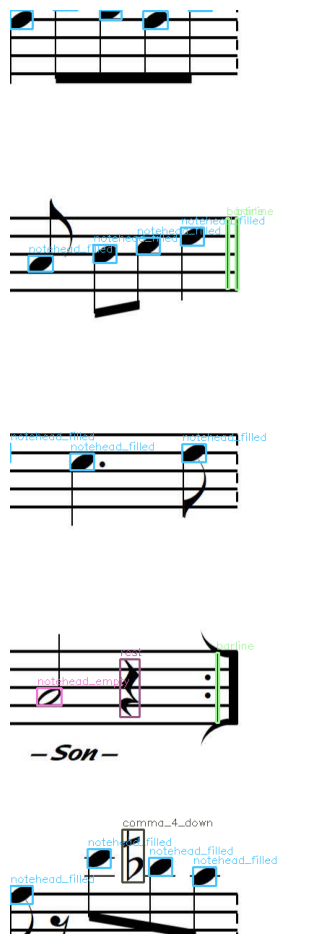

Displaying: f1f55240-page1_6.png


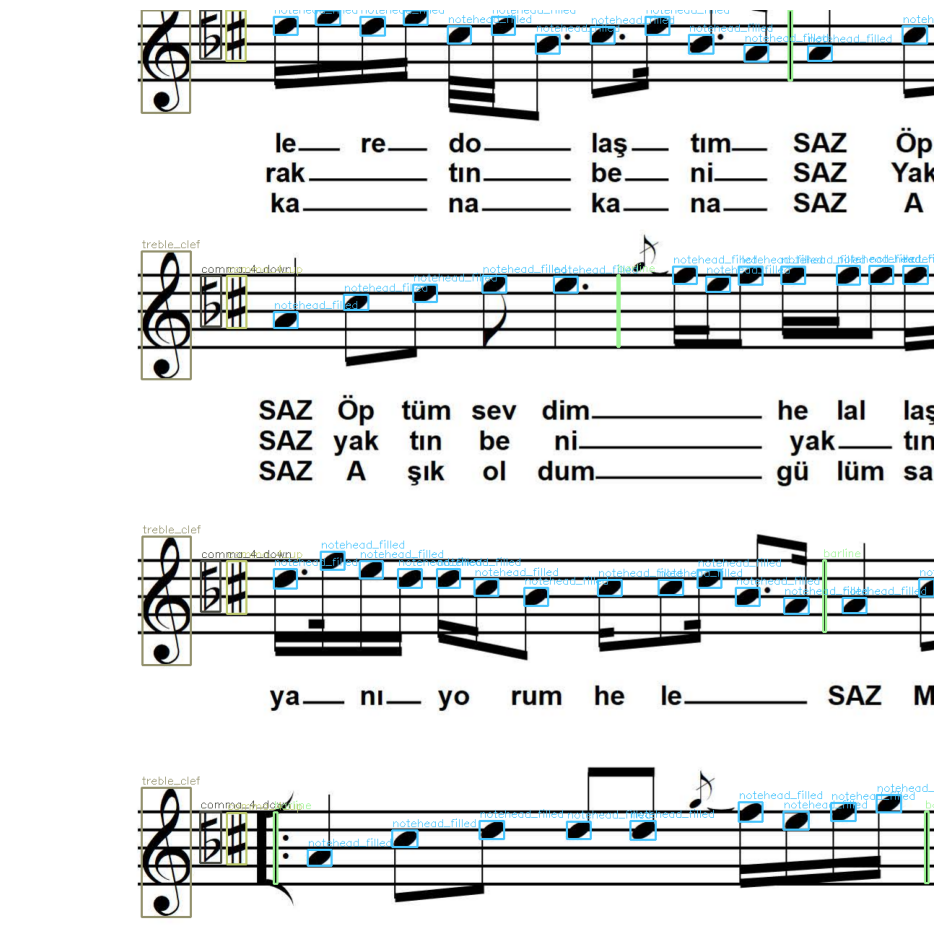

Displaying: f1f55240-page1_2.png


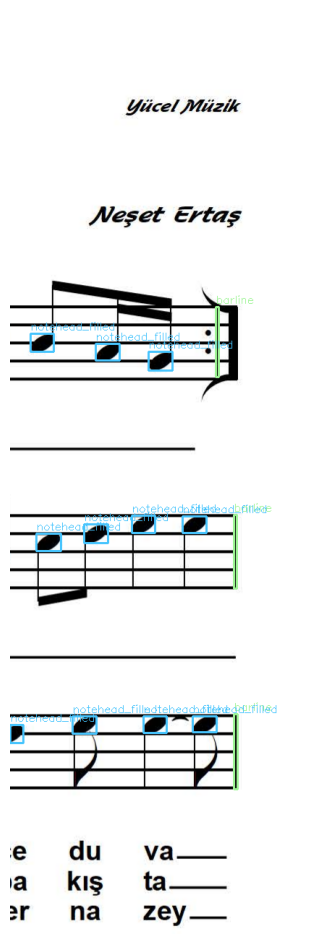

Displaying: 08a9d36e-page1_6.png


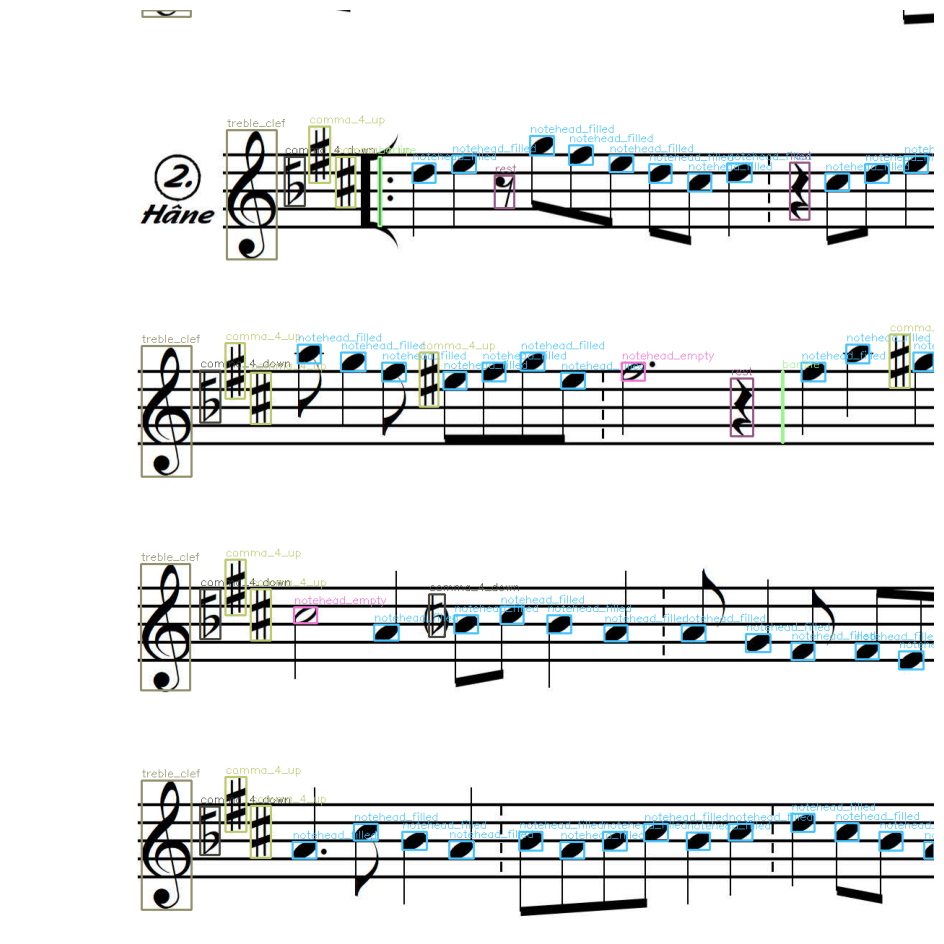

Displaying: f1f55240-page1_4.png


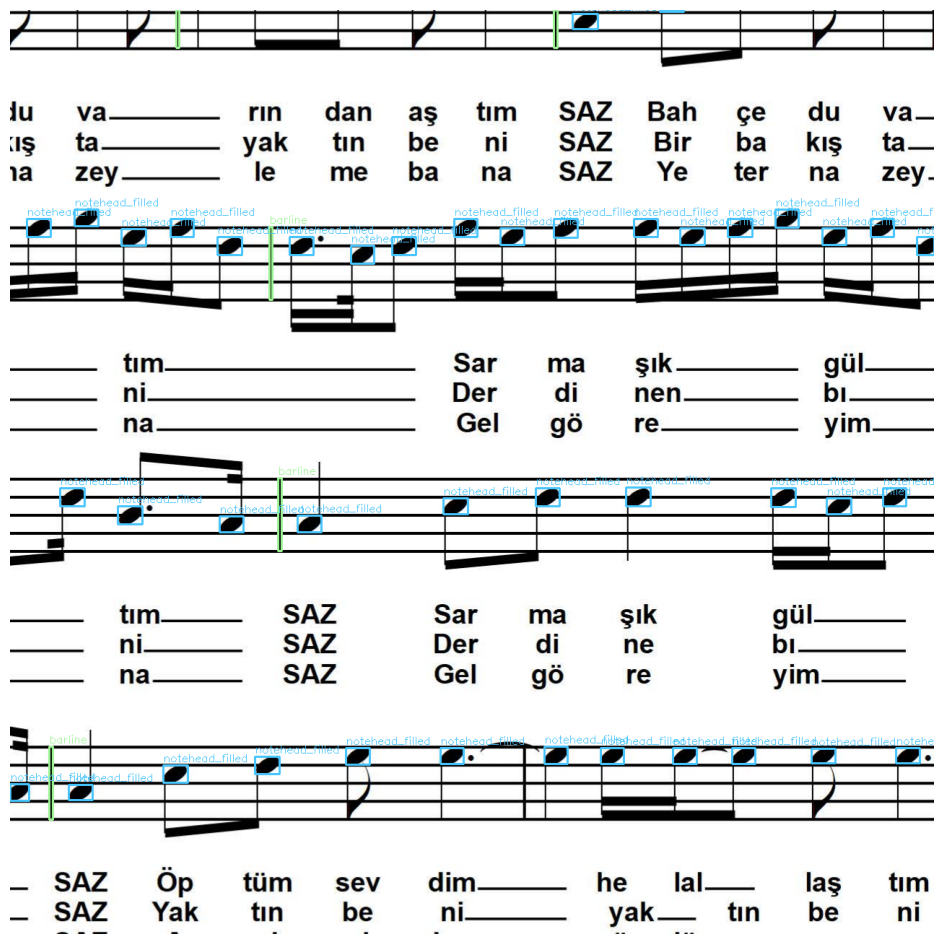

In [20]:
for _ in range(5):
    img_name = np.random.choice(image_files)
    print("Displaying:", img_name)

    img_path = os.path.join(IMAGE_DIR, img_name)
    label_path = os.path.join(
        LABEL_DIR,
        img_name.replace(".png", ".txt")
    )

    img = cv2.imread(img_path)
    h, w = img.shape[:2]


    # -----------------------------
    # Draw bounding boxes
    # -----------------------------

    if os.path.exists(label_path):

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:
            cls, x, y, bw, bh = map(float, line.split())

            # convert to absolute coords
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            # random color per class
            random.seed(int(cls))
            color = (
                random.randint(50, 255),
                random.randint(50, 255),
                random.randint(50, 255)
            )

            cv2.rectangle(
                img,
                (x1, y1),
                (x2, y2),
                color,
                2
            )

            label = CLASS_NAMES[int(cls)]

            cv2.putText(
                img,
                label,
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                1
            )

    else:
        print("No labels found")



    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,12))
    plt.imshow(img_rgb)
    plt.axis("off") 
    plt.show()